A condição de estabilidade foi satisfeita.


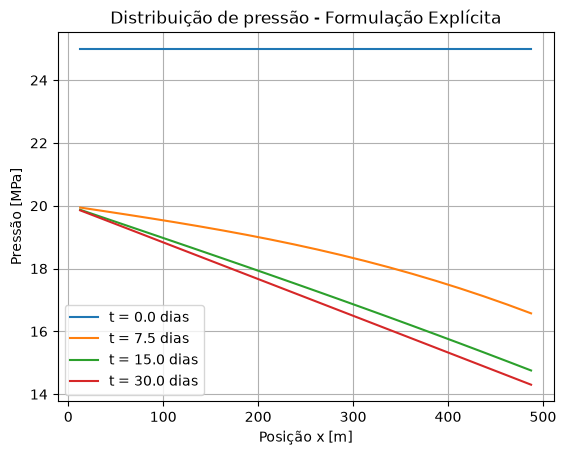

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from mdf.explicita import explicita_1d_PF

Pi=25e6                 # pressão inicial [Pa]
Pw=20e6                 # pressão prescrita na borda esquerda [Pa]

qw=-100/86400            # vazão [m^3/s] = 100 m^3/dia

h=20                    # espessura [m]
L=500                   #comprimento do reservatório [m]
largura=100             # largura do reservatório [m]
A=h*largura

k = 100 * 9.869233e-16     # permeabilidade [m^2] = 100 mD
phi=0.20                   # porosidade 
ct=1e-9                 # compressibilidade total [1/Pa]
mu=2e-3                  # viscosidade [Pa.s] = 2 cP

t_final=30*86400        # 30 dias em segundos

nx=20 #passo de espaço
nt=5000 #passo de tempo


x, t, P, lambd = explicita_1d_PF(
    Pi,
    Pw,
    qw,
    h,
    L,
    largura,
    k,
    phi,
    ct,
    mu,
    t_final,
    nx,
    nt,
)

#gráfico
fracoes_tempo = [0, 0.25, 0.50, 1.0]

plt.figure()

for f in fracoes_tempo:

    indice = int(f * nt)

    tempo_dias = t[indice] / 86400

    plt.plot(
        x,
        P[indice, :] / 1e6,
        label=f"t = {tempo_dias:.1f} dias"
    )

plt.xlabel("Posição x [m]")
plt.ylabel("Pressão [MPa]")
plt.title("Distribuição de pressão - Formulação Explícita")

plt.grid()
plt.legend()
plt.show()
